<a href="https://colab.research.google.com/github/RamcharanChandragiri/MACHINE-LEARNING/blob/main/ML_Lab_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SUBTASK-01**

Gradient Boosting: Applying XGBoost/GBoost using libraries and comparing
performance.

Kaggle Dataset Link: https://www.kaggle.com/competitions/titanic?

Tasks:
1. Preprocess data (missing values, encoding).
2. Train:
Decision Tree Classifier
GradientBoostingClassifier
XGBoost Classifier
3. Evaluate using Accuracy, Precision, Recall, F1-score.
4. Compare confusion matrices.
5. Conclude which boosting method performs best


In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [2]:
# =========================
# 2. LOAD DATASET
# =========================
# Download train.csv from Kaggle Titanic dataset and place in same folder
df = pd.read_csv("titanic_train.csv")

print("First 5 rows:")
print(df.head())

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [3]:
# =========================
# 3. DATA PREPROCESSING
# =========================

# Drop Cabin (too many missing values)
df.drop(columns=['Cabin'], inplace=True)

# Fill missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Encode categorical variables
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# Drop unnecessary columns
df.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)


/tmp/ipykernel_919/1776640121.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_919/1776640121.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [4]:
# =========================
# 4. SPLIT DATA
# =========================
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
# =========================
# 5. TRAIN MODELS
# =========================

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

# XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:36:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [6]:
# =========================
# 6. EVALUATION FUNCTION
# =========================
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Performance:")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Evaluate all models
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)
evaluate_model("XGBoost", y_test, y_pred_xgb)


Decision Tree Performance:
Accuracy : 0.7821229050279329
Precision: 0.7215189873417721
Recall   : 0.7702702702702703
F1-score : 0.7450980392156863

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81       105
           1       0.72      0.77      0.75        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.78      0.78       179


Gradient Boosting Performance:
Accuracy : 0.8100558659217877
Precision: 0.8125
Recall   : 0.7027027027027027
F1-score : 0.7536231884057971

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       105
           1       0.81      0.70      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179


XGBoost

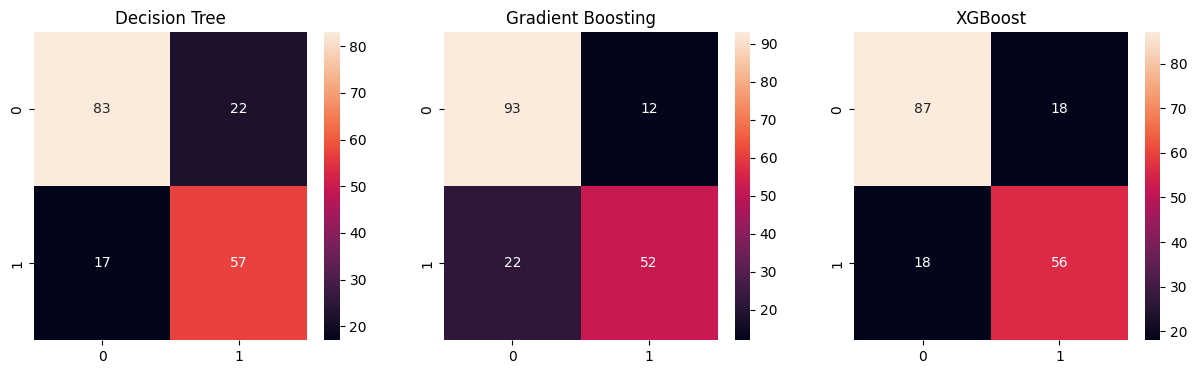

In [7]:
# =========================
# 7. CONFUSION MATRICES
# =========================
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_gb = confusion_matrix(y_test, y_pred_gb)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plot confusion matrices
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Decision Tree")

plt.subplot(1, 3, 2)
sns.heatmap(cm_gb, annot=True, fmt='d')
plt.title("Gradient Boosting")

plt.subplot(1, 3, 3)
sns.heatmap(cm_xgb, annot=True, fmt='d')
plt.title("XGBoost")

plt.show()


Model Comparison:
               Model  Accuracy  Precision    Recall  F1-score
0      Decision Tree  0.782123   0.721519  0.770270  0.745098
1  Gradient Boosting  0.810056   0.812500  0.702703  0.753623
2            XGBoost  0.798883   0.756757  0.756757  0.756757


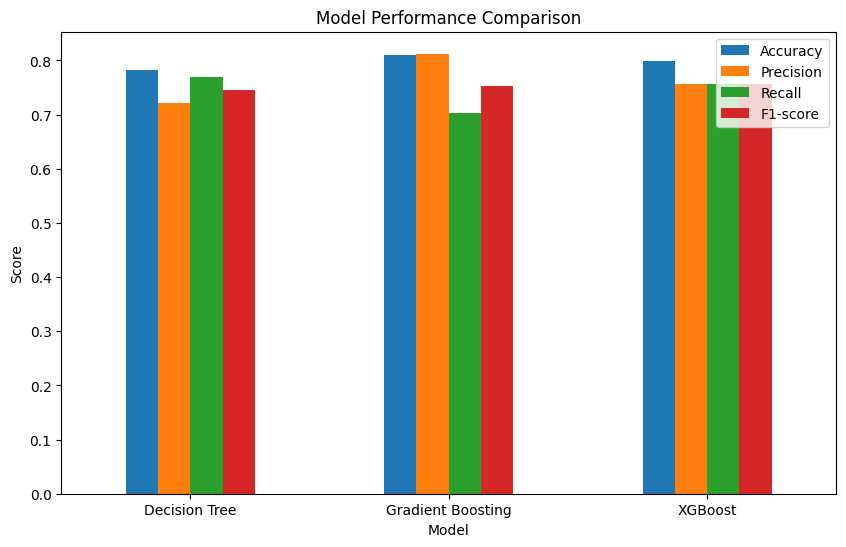


Best Model Based on Accuracy:
Model        Gradient Boosting
Accuracy              0.810056
Precision               0.8125
Recall                0.702703
F1-score              0.753623
Name: 1, dtype: object


In [8]:
# =========================
# 8. PERFORMANCE COMPARISON
# =========================
results = pd.DataFrame({
    "Model": ["Decision Tree", "Gradient Boosting", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_xgb)
    ]
})

print("\nModel Comparison:")
print(results)

# Optional: Bar plot comparison
results.set_index("Model").plot(kind='bar', figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

# =========================
# 9. CONCLUSION
# =========================
best_model = results.loc[results['Accuracy'].idxmax()]
print("\nBest Model Based on Accuracy:")
print(best_model)

**SUBTASK-02**

Gradient Boosting: Applying XGBoost/GBoost using libraries and comparing
performance.

Kaggle Dataset Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-
data?

Tasks:
1. Scale features using StandardScaler.
2. Train:
Random Forest
GradientBoostingClassifier
XGBoost Classifier
3. Compare models using Accuracy and ROC-AUC.
4. Plot ROC curves.
5. Discuss why boosting improves classification accuracy.


In [9]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

In [10]:
# =========================
# 2. LOAD DATASET
# =========================
# Download dataset from Kaggle and place in same folder
df = pd.read_csv("data.csv")

# Drop unnecessary column
df.drop(columns=['id'], inplace=True)

# Convert diagnosis (M = 1, B = 0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [11]:
# =========================
# 3. SPLIT DATA
# =========================
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [12]:
# =========================
# 4. FEATURE SCALING
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [14]:
# =========================
# 5. TRAIN MODELS
# =========================

# Handle NaNs introduced by scaling (likely due to zero-variance features)
# Replacing NaNs with 0 in scaled data as a workaround to allow models to train.
X_train_scaled_cleaned = np.nan_to_num(X_train_scaled)
X_test_scaled_cleaned = np.nan_to_num(X_test_scaled)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled_cleaned, y_train)

# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_scaled_cleaned, y_train)

# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_scaled_cleaned, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:49:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [16]:
# =========================
# 6. PREDICTIONS
# =========================
y_pred_rf = rf.predict(X_test_scaled_cleaned)
y_pred_gb = gb.predict(X_test_scaled_cleaned)
y_pred_xgb = xgb.predict(X_test_scaled_cleaned)

# Probabilities for ROC
y_prob_rf = rf.predict_proba(X_test_scaled_cleaned)[:, 1]
y_prob_gb = gb.predict_proba(X_test_scaled_cleaned)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test_scaled_cleaned)[:, 1]

In [17]:
# =========================
# 7. EVALUATION
# =========================
def evaluate(name, y_test, y_pred, y_prob):
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print(f"\n{name}")
    print("Accuracy :", acc)
    print("ROC-AUC  :", roc)

    return acc, roc

rf_acc, rf_roc = evaluate("Random Forest", y_test, y_pred_rf, y_prob_rf)
gb_acc, gb_roc = evaluate("Gradient Boosting", y_test, y_pred_gb, y_prob_gb)
xgb_acc, xgb_roc = evaluate("XGBoost", y_test, y_pred_xgb, y_prob_xgb)


Random Forest
Accuracy : 0.9649122807017544
ROC-AUC  : 0.996069439895185

Gradient Boosting
Accuracy : 0.956140350877193
ROC-AUC  : 0.9950867998689813

XGBoost
Accuracy : 0.956140350877193
ROC-AUC  : 0.9908286930887651


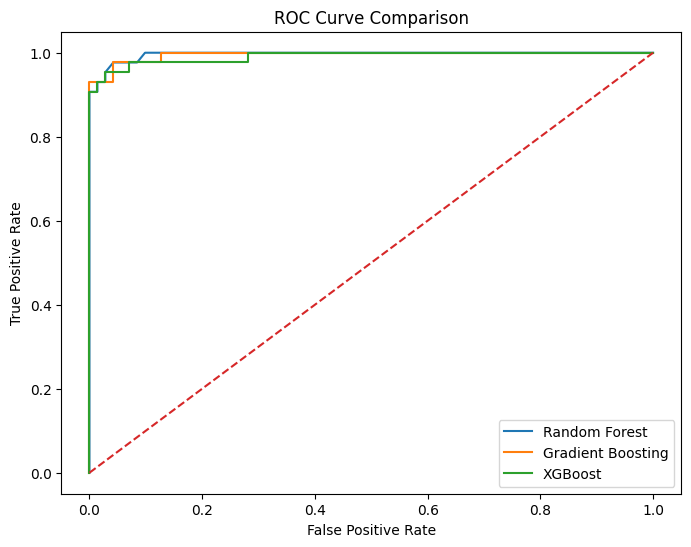

In [18]:
# =========================
# 8. ROC CURVE PLOTTING
# =========================
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

plt.plot([0,1], [0,1], linestyle='--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [19]:
#========================
# 9. COMPARISON TABLE
# =========================
results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "XGBoost"],
    "Accuracy": [rf_acc, gb_acc, xgb_acc],
    "ROC-AUC": [rf_roc, gb_roc, xgb_roc]
})

print("\nModel Comparison:")
print(results)

# =========================
# 10. BEST MODEL
# =========================
best_model = results.loc[results['ROC-AUC'].idxmax()]
print("\nBest Model Based on ROC-AUC:")
print(best_model)


Model Comparison:
               Model  Accuracy   ROC-AUC
0      Random Forest  0.964912  0.996069
1  Gradient Boosting  0.956140  0.995087
2            XGBoost  0.956140  0.990829

Best Model Based on ROC-AUC:
Model       Random Forest
Accuracy         0.964912
ROC-AUC          0.996069
Name: 0, dtype: object


**SUBTASK-03**

Gradient Boosting: Applying XGBoost/GBoost using libraries and comparing
performance.
Kaggle Dataset Link: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques?
Tasks:
1. Select important numeric features and handle missing values.
2. Train:
Linear Regression
GradientBoostingRegressor
XGBoost Regressor
3. Evaluate using RMSE and R² score.
4. Compare predicted vs actual values.
5. Identify the best regression model.


In [20]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_squared_error, r2_score

In [21]:
# =========================
# 2. LOAD DATASET
# =========================
# Download train.csv from Kaggle and place in same folder
df = pd.read_csv("housetrain.csv")

print(df.head())


   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [22]:
# =========================
# 3. SELECT NUMERIC FEATURES
# =========================
numeric_df = df.select_dtypes(include=[np.number])

# Drop target from features
X = numeric_df.drop("SalePrice", axis=1)
y = numeric_df["SalePrice"]

# =========================
# 4. HANDLE MISSING VALUES
# =========================
imputer = SimpleImputer(strategy='median')

X_imputed = imputer.fit_transform(X)

# =========================
# 5. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)


In [23]:
# =========================
# 6. TRAIN MODELS
# =========================

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

# XGBoost Regressor
xgbr = XGBRegressor(objective='reg:squarederror')
xgbr.fit(X_train, y_train)
y_pred_xgb = xgbr.predict(X_test)


In [24]:
# =========================
# 7. EVALUATION FUNCTION
# =========================
def evaluate(name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}")
    print("RMSE :", rmse)
    print("R²   :", r2)

    return rmse, r2

lr_rmse, lr_r2 = evaluate("Linear Regression", y_test, y_pred_lr)
gbr_rmse, gbr_r2 = evaluate("Gradient Boosting", y_test, y_pred_gbr)
xgb_rmse, xgb_r2 = evaluate("XGBoost", y_test, y_pred_xgb)


Linear Regression
RMSE : 36879.81932192757
R²   : 0.8226775450640439

Gradient Boosting
RMSE : 28124.76994869818
R²   : 0.8968749615986314

XGBoost
RMSE : 29380.36242118194
R²   : 0.8874616622924805


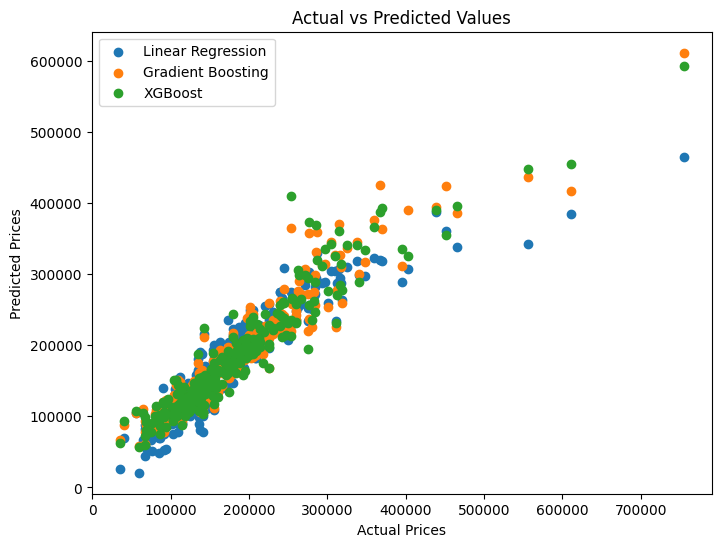

In [25]:
# =========================
# 8. PREDICTED vs ACTUAL PLOT
# =========================
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_lr, label="Linear Regression")
plt.scatter(y_test, y_pred_gbr, label="Gradient Boosting")
plt.scatter(y_test, y_pred_xgb, label="XGBoost")

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()


In [26]:
# =========================
# 9. COMPARISON TABLE
# =========================
results = pd.DataFrame({
    "Model": ["Linear Regression", "Gradient Boosting", "XGBoost"],
    "RMSE": [lr_rmse, gbr_rmse, xgb_rmse],
    "R2 Score": [lr_r2, gbr_r2, xgb_r2]
})

print("\nModel Comparison:")
print(results)

# =========================
# 10. BEST MODEL
# =========================
best_model = results.loc[results['R2 Score'].idxmax()]
print("\nBest Model Based on R² Score:")
print(best_model)


Model Comparison:
               Model          RMSE  R2 Score
0  Linear Regression  36879.819322  0.822678
1  Gradient Boosting  28124.769949  0.896875
2            XGBoost  29380.362421  0.887462

Best Model Based on R² Score:
Model       Gradient Boosting
RMSE             28124.769949
R2 Score             0.896875
Name: 1, dtype: object


**SUBTASK-04**

Gradient Boosting: Applying XGBoost/GBoost using libraries and comparing performance.

Kaggle Dataset Link: https://www.kaggle.com/datasets/mirichoi0218/insurance?

Tasks:
1. Encode categorical variables and scale features.
2. Train:
Linear Regression
GradientBoostingRegressor
XGBoost Regressor
3. Evaluate using MAE, RMSE, and R².
4. Analyze feature importance from XGBoost.
5. Conclude the impact of boosting on prediction accuracy

In [27]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
# =========================
# 2. LOAD DATASET
# =========================
# Download insurance.csv from Kaggle and place in same folder
df = pd.read_csv("insurance.csv")

print(df.head())

# =========================
# 3. ENCODE CATEGORICAL VARIABLES
# =========================
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [29]:
# =========================
# 4. SPLIT DATA
# =========================
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 5. FEATURE SCALING
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
# =========================
# 6. TRAIN MODELS
# =========================

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train_scaled, y_train)
y_pred_gbr = gbr.predict(X_test_scaled)

# XGBoost Regressor
xgb = XGBRegressor(objective='reg:squarederror')
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)

In [31]:
# =========================
# 7. EVALUATION FUNCTION
# =========================
def evaluate(name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}")
    print("MAE  :", mae)
    print("RMSE :", rmse)
    print("R²   :", r2)

    return mae, rmse, r2

lr_mae, lr_rmse, lr_r2 = evaluate("Linear Regression", y_test, y_pred_lr)
gbr_mae, gbr_rmse, gbr_r2 = evaluate("Gradient Boosting", y_test, y_pred_gbr)
xgb_mae, xgb_rmse, xgb_r2 = evaluate("XGBoost", y_test, y_pred_xgb)


Linear Regression
MAE  : 4186.508898366436
RMSE : 5799.5870914383595
R²   : 0.7833463107364536

Gradient Boosting
MAE  : 2446.925720308309
RMSE : 4351.106228083052
R²   : 0.8780529462228404

XGBoost
MAE  : 2791.8325179517183
RMSE : 4822.991168492682
R²   : 0.8501678977480663


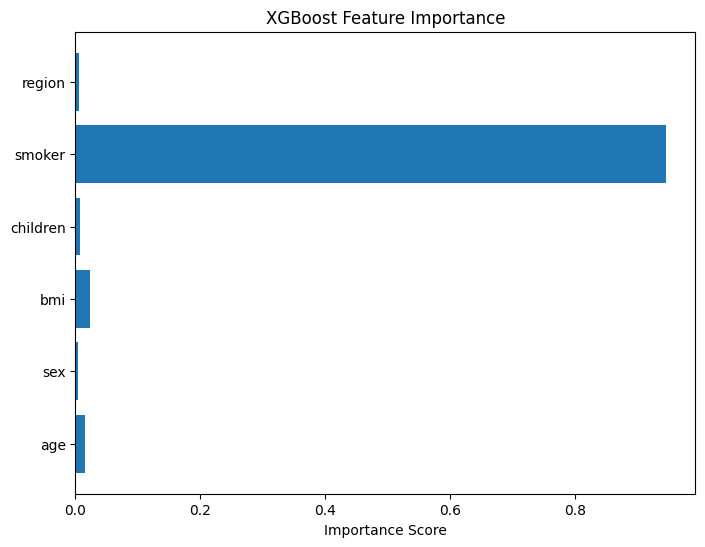


Model Comparison:
               Model          MAE         RMSE  R2 Score
0  Linear Regression  4186.508898  5799.587091  0.783346
1  Gradient Boosting  2446.925720  4351.106228  0.878053
2            XGBoost  2791.832518  4822.991168  0.850168

Best Model Based on R² Score:
Model       Gradient Boosting
MAE                2446.92572
RMSE              4351.106228
R2 Score             0.878053
Name: 1, dtype: object


In [32]:
# =========================
# 8. FEATURE IMPORTANCE (XGBoost)
# =========================
importance = xgb.feature_importances_
features = X.columns

# Plot feature importance
plt.figure(figsize=(8,6))
plt.barh(features, importance)
plt.xlabel("Importance Score")
plt.title("XGBoost Feature Importance")
plt.show()

# =========================
# 9. MODEL COMPARISON
# =========================
results = pd.DataFrame({
    "Model": ["Linear Regression", "Gradient Boosting", "XGBoost"],
    "MAE": [lr_mae, gbr_mae, xgb_mae],
    "RMSE": [lr_rmse, gbr_rmse, xgb_rmse],
    "R2 Score": [lr_r2, gbr_r2, xgb_r2]
})

print("\nModel Comparison:")
print(results)

# =========================
# 10. BEST MODEL
# =========================
best_model = results.loc[results['R2 Score'].idxmax()]
print("\nBest Model Based on R² Score:")
print(best_model)

**SUBTASK-05**

Gradient Boosting: Applying XGBoost/GBoost using libraries and comparing
performance.

Kaggle Dataset Link:
https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset?

Tasks:
1. Preprocess dataset and split into train/test sets.
2. Train XGBoost models with varying:
n_estimators
max_depth
learning_rate
3. Compare results with:
Decision Tree
Random Forest
4. Evaluate using Accuracy and ROC-AUC.
5. Identify optimal hyperparameters and justify.


In [33]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

In [34]:
# =========================
# 2. LOAD DATASET
# =========================
# Download dataset and place in same folder
df = pd.read_csv("UCI_Credit_Card.csv")

print(df.head())

# =========================
# 3. PREPROCESSING
# =========================

# Rename target column
df.rename(columns={'default.payment.next.month': 'target'}, inplace=True)

# Drop ID column
df.drop(columns=['ID'], inplace=True)

# Features & Target
X = df.drop('target', axis=1)
y = df['target']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0       0.0   

In [35]:
# =========================
# 4. BASE MODELS
# =========================

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [36]:
# =========================
# 5. XGBOOST WITH DIFFERENT PARAMETERS
# =========================

results_xgb = []

param_grid = [
    {"n_estimators":100, "max_depth":3, "learning_rate":0.1},
    {"n_estimators":200, "max_depth":4, "learning_rate":0.05},
    {"n_estimators":300, "max_depth":5, "learning_rate":0.01}
]

for params in param_grid:
    model = XGBClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        use_label_encoder=False,
        eval_metric='logloss'
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results_xgb.append({
        "params": params,
        "accuracy": acc,
        "roc_auc": roc
    })


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:06:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:06:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:06:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [37]:
# =========================
# 6. EVALUATION FUNCTION
# =========================
def evaluate(name, y_test, y_pred, y_prob):
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print(f"\n{name}")
    print("Accuracy :", acc)
    print("ROC-AUC  :", roc)

    return acc, roc

dt_acc, dt_roc = evaluate("Decision Tree", y_test, y_pred_dt, y_prob_dt)
rf_acc, rf_roc = evaluate("Random Forest", y_test, y_pred_rf, y_prob_rf)
# 7. DISPLAY XGBOOST RESULTS
# =========================
print("\nXGBoost Hyperparameter Results:")
for res in results_xgb:
    print(res)

# Find best XGBoost model
best_xgb = max(results_xgb, key=lambda x: x['roc_auc'])
print("\nBest XGBoost Parameters:")
print(best_xgb)


Decision Tree
Accuracy : 0.7255
ROC-AUC  : 0.6110862132478697

Random Forest
Accuracy : 0.816
ROC-AUC  : 0.7577788444679593

XGBoost Hyperparameter Results:
{'params': {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}, 'accuracy': 0.8208333333333333, 'roc_auc': np.float64(0.7842724549161355)}
{'params': {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05}, 'accuracy': 0.8195, 'roc_auc': np.float64(0.7835159588893849)}
{'params': {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01}, 'accuracy': 0.8211666666666667, 'roc_auc': np.float64(0.7840230249083894)}

Best XGBoost Parameters:
{'params': {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}, 'accuracy': 0.8208333333333333, 'roc_auc': np.float64(0.7842724549161355)}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:06:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


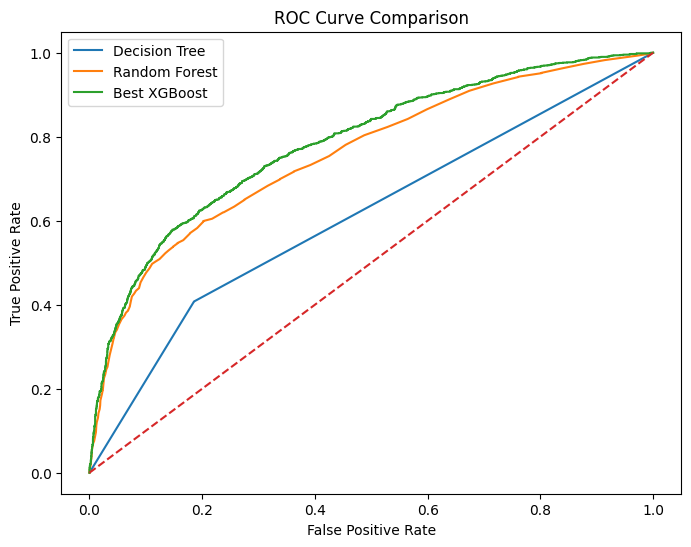

In [38]:
# =========================
# 8. ROC CURVE COMPARISON
# =========================
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

# Best XGB ROC
best_model = XGBClassifier(
    n_estimators=best_xgb["params"]["n_estimators"],
    max_depth=best_xgb["params"]["max_depth"],
    learning_rate=best_xgb["params"]["learning_rate"],
    use_label_encoder=False,
    eval_metric='logloss'
)

best_model.fit(X_train, y_train)
y_prob_best = best_model.predict_proba(X_test)[:,1]

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_best)
plt.plot(fpr_xgb, tpr_xgb, label="Best XGBoost")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()